# Notebook 1: Data Cleaning and Quality Control

In [65]:
#load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from itertools import combinations
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

## Step 1: Load Proteomics Data


In [66]:
# Load the data: proteins as rows, patients as columns
data = pd.read_csv('proteomics_data.txt', sep='\t', index_col=0)
data.head()

,Patient_1,Patient_2,Patient_3,Patient_4,Patient_5,Patient_6,Patient_7,Patient_8,Patient_9,Patient_10,...,Patient_109,Patient_110,Patient_111,Patient_112,Patient_113,Patient_114,Patient_115,Patient_116,Patient_117,Patient_118
A1BG,-0.248427,0.34238,-0.422836,0.523159,0.838483,0.104756,0.152693,-0.307978,0.015145,-0.250013,...,0.604403,0.120395,0.276506,-0.224080,-0.193982,0.258954,0.061537,0.370149,0.490885,0.185676
A1CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2M,-1.204522,-0.32958,-0.680533,0.075529,1.109671,-0.513389,-0.064456,-1.147968,-0.035746,-1.178612,...,0.886675,-0.689876,0.328976,-0.685488,-1.077732,-0.347891,-0.466748,1.296028,1.295298,-0.273764
A2ML1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.896183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A4GALT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
data.shape

(12241, 118)

In [68]:
print(f'Data: {data.shape[0]:,} proteins X {data.shape[1]} patients')

Data: 12,241 proteins X 118 patients


In [69]:
# check if we have non numeric columns
data.select_dtypes(exclude='number').columns

Index([], dtype='object')

In [70]:
print(f'Missing Values: {data.isna().sum().sum():,}')

Missing Values: 244,858


## Step 2: Handle Missing Values


### 1. Filtering

In [71]:
# remove proteins that were detected in below 50% of patients
MIN_DETECTION = 0.50
detection_rate = data.notna().mean(axis=1)

data_filtered = data[detection_rate >= MIN_DETECTION].copy()

n_removed = data.shape[0] - data_filtered.shape[0]
print(f'Proteins before filtering: {data.shape[0]:,}')
print(f'Proteins after filtering:  {data_filtered.shape[0]:,}')
print(f'Proteins removed:{n_removed:,}')

Proteins before filtering: 12,241
Proteins after filtering:  10,164
Proteins removed:2,077


### 2. Imputation

In [72]:
data_imputed = data_filtered.copy()

for protein in data_imputed.index:
    row = data_imputed.loc[protein]
    if row.isna().sum() > 0:
        # calculate the distribution properties of the detected values
        mean_detected = row.mean()
        std_detected = row.std() if pd.notna(row.std()) and row.std() > 0 else 0.1
        
        # shift the distribution down to simulate the lower limit of detection
        # typically shifted down by 1.8 standard deviations, with a shrunk width (0.3)
        impute_mean = mean_detected - (1.8 * std_detected)
        impute_std = 0.3 * std_detected
        
        # generate random values from this lower tail distribution to fill NAs
        num_nas = row.isna().sum()
        random_values = np.random.normal(impute_mean, impute_std, num_nas)
        
        # map back to the dataframe
        data_imputed.loc[protein, row.isna()] = random_values

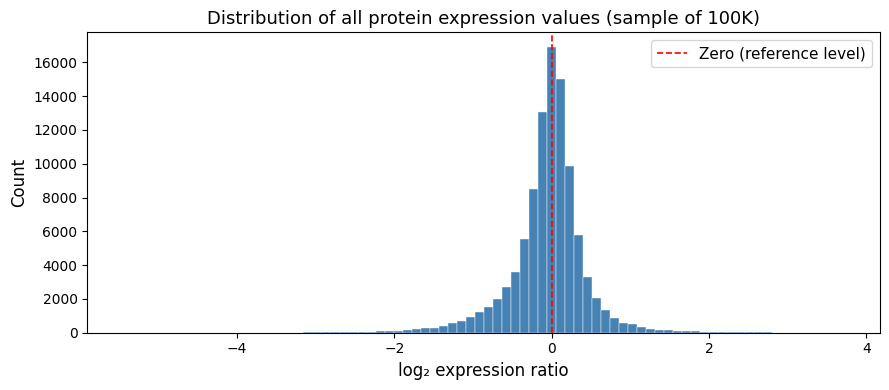

In [73]:
# Distribution graph
all_values = data_imputed.values.flatten()
sample_vals = np.random.choice(all_values, size=min(100000, len(all_values)), replace=False)

plt.figure(figsize=(9, 4))
plt.hist(sample_vals, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero (reference level)')
plt.xlabel('log₂ expression ratio', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of all protein expression values (sample of 100K)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('outputs/figures/nb1v2_value_distribution.png', dpi=150)

## Step 3: Load CORUM Gold Standard


In [74]:
# Load the CORUM database
corum_raw = pd.read_csv('CORUM_data.txt', sep='\t')
corum_raw.head()

,ComplexID,ComplexName,Organism,Synonyms,Cell.line,subunits.UniProt.IDs.,subunits.Entrez.IDs.,Protein.complex.purification.method,GO.ID,GO.description,FunCat.ID,FunCat.description,PubMed.ID,Complex.comment,Disease.comment,Subunits.comment,SWISSPROT.organism,subunits.Protein.name.,subunits.Gene.name.,subunits.Gene.name.syn.
1,1,BCL6-HDAC4 complex,Human,NaN,U2OS osteosarcoma-derived UTA-L cells,P41182;P56524,604;9759,MI:0007-anti tag coimmunoprecipitation,GO:0006265;GO:0045892;GO:0051276;GO:0030183;GO...,DNA topological change;negative regulation of ...,10.01.09.05;11.02.03.04.03;42.10.03;43.03.07.0...,DNA conformation modification (e.g. chromatin)...,11929873,Transcriptional repression by BCL6 is thought ...,NaN,NaN,Homo sapiens (Human);Homo sapiens (Human),B-cell lymphoma 6 protein;Histone deacetylase 4,BCL6;HDAC4,BCL5 LAZ3 ZBTB27 ZNF51;KIAA0288
2,2,BCL6-HDAC5 complex,Human,NaN,U2OS osteosarcoma-derived UTA-L cells,P41182;Q9UQL6,604;10014,MI:0007-anti tag coimmunoprecipitation,GO:0006265;GO:0045892;GO:0051276;GO:0030183;GO...,DNA topological change;negative regulation of ...,10.01.09.05;11.02.03.04.03;42.10.03;43.03.07.0...,DNA conformation modification (e.g. chromatin)...,11929873,Transcriptional repression by BCL6 is thought ...,NaN,NaN,Homo sapiens (Human);Homo sapiens (Human),B-cell lymphoma 6 protein;Histone deacetylase 5,BCL6;HDAC5,BCL5 LAZ3 ZBTB27 ZNF51;KIAA0600
3,3,BCL6-HDAC7 complex,Human,NaN,U2OS osteosarcoma-derived UTA-L cells,P41182;Q8WUI4,604;51564,MI:0007-anti tag coimmunoprecipitation,GO:0006265;GO:0045892;GO:0051276;GO:0030183;GO...,DNA topological change;negative regulation of ...,10.01.09.05;11.02.03.04.03;42.10.03;43.03.07.0...,DNA conformation modification (e.g. chromatin)...,11929873,Transcriptional repression by BCL6 is thought ...,NaN,NaN,Homo sapiens (Human);Homo sapiens (Human),B-cell lymphoma 6 protein;Histone deacetylase 7,BCL6;HDAC7,BCL5 LAZ3 ZBTB27 ZNF51;HDAC7A
4,4,Multisubunit ACTR coactivator complex,Human,NaN,different human tissues and cancer cell lines,Q09472;Q92793;Q92831;Q9Y6Q9,2033;1387;8850;8202,MI:0004-affinity chromatography technology;MI:...,GO:0030374;GO:0004402,nuclear receptor coactivator activity;histone ...,NaN,NaN,9267036,Cofactor ACTR binds directly nuclear receptors...,NaN,NaN,Homo sapiens (Human);Homo sapiens (Human);Homo...,Histone acetyltransferase p300;CREB-binding pr...,EP300;CREBBP;KAT2B;NCOA3,"P300;CBP;PCAF;AIB1, BHLHE42, RAC3, TRAM1, ACTR"
5,10,Condensin I complex,Human,13S condensin complex,HeLa cells,O95347;Q15003;Q15021;Q9BPX3;Q9NTJ3,10592;23397;9918;64151;10051,MI:0004-affinity chromatography technology;MI:...,GO:0000279;GO:0030261;GO:0007059;GO:0051276;GO...,M phase;chromosome condensation;chromosome seg...,10.03.01.01.11;10.03.04.03;10.03.04.05;42.10.0...,M phase;chromosome condensation;chromosome seg...,11136719,NaN,NaN,NaN,Homo sapiens (Human);Homo sapiens (Human);Homo...,Structural maintenance of chromosomes protein ...,SMC2;NCAPH;NCAPD2;NCAPG;SMC4,CAPE SMC2L1;BRRN BRRN1 CAPH KIAA0074;CAPD2 CNA...


In [75]:
corum_raw.shape, corum_raw["Organism"].unique()

((3627, 20), array(['Human'], dtype=object))

In [76]:
# set of all proteins in our filtered dataset
our_proteins = set(data_imputed.index)

# store all CORUM positive pairs
gold_pairs = set()  

# the gene name column in this CORUM file is 'subunits.Gene.name.'
subunit_col = 'subunits.Gene.name.'

for _, row in corum_raw.iterrows():
    if pd.isna(row[subunit_col]):
        continue
    
    # split into individual genes
    genes = [g.strip() for g in str(row[subunit_col]).split(';') if g.strip()]
    
    # keep only genes present in our dataset
    genes_in_data = [g for g in genes if g in our_proteins]
    
    # generate all pairwise combinations
    for a, b in combinations(genes_in_data, 2):
        # store as sorted tuple to avoid duplicates (A,B) and (B,A)
        gold_pairs.add(tuple(sorted([a, b])))

# convert to list for saving
gold_pairs = list(gold_pairs)

print(f'Gold standard (CORUM) pairs: {len(gold_pairs):,}')

Gold standard (CORUM) pairs: 39,430


In [77]:
# pairs generated
gold_pairs[:-3][:3]

[('PRPF4', 'SNRPG'), ('CIRBP', 'TRA2B'), ('BCAS2', 'PPP1CA')]

In [78]:
# saving our data
data_imputed.to_csv('outputs/data_imputed.tsv', sep='\t')
print(f'File saved to: outputs/data_imputed.tsv ({data_imputed.shape[0]:,} proteins, {data_imputed.shape[1]} patients)')

File saved to: outputs/data_imputed.tsv (10,164 proteins, 118 patients)


In [79]:
# saving gold pairs
with open('outputs/gold_pairs.pkl', 'wb') as f:
    pickle.dump(gold_pairs, f)
print(f'File saved to: outputs/gold_pairs.pkl saved ({len(gold_pairs):,} CORUM pairs)')

File saved to: outputs/gold_pairs.pkl saved (39,430 CORUM pairs)
